# Классификация kNN

In [1]:
import pandas as pd
import kagglehub
import os
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np

from ucimlrepo import fetch_ucirepo
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

## Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

   > Возможно, потребуется использовать два датасета: один для бинарной классификации, второй для многоклассовой.
   > Использование встроенных в `sklearn` датасетов или их аналогов с Kaggle не допускается.

Ссылка на источник: https://www.kaggle.com/datasets/adilshamim8/math-students

In [2]:
path = kagglehub.dataset_download("adilshamim8/math-students")
os.listdir(path)

['Math-Students.csv']

In [3]:
file_path = os.path.join(path, 'Math-Students.csv')
df = pd.read_csv(file_path)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Ссылка на источник: https://archive.ics.uci.edu/dataset/149/statlog+vehicle+silhouettes

In [4]:
# fetch dataset
statlog_vehicle_silhouettes = fetch_ucirepo(id=149) 

# data (as pandas dataframes)
X_data = statlog_vehicle_silhouettes.data.features
y_data = statlog_vehicle_silhouettes.data.targets
df2 = pd.concat([X_data, y_data], axis=1)

statlog_vehicle_silhouettes.variables

,name,role,type,demographic,description,units,missing_values
0,COMPACTNESS,Feature,Integer,None,None,None,no
1,CIRCULARITY,Feature,Integer,None,None,None,no
2,DISTANCE CIRCULARITY,Feature,Integer,None,None,None,no
3,RADIUS RATIO,Feature,Integer,None,None,None,no
4,PR.AXIS ASPECT RATIO,Feature,Integer,None,None,None,no
5,MAX.LENGTH ASPECT RATIO,Feature,Integer,None,None,None,no
6,SCATTER RATIO,Feature,Integer,None,None,None,no
7,ELONGATEDNESS,Feature,Integer,None,None,None,no
8,PR.AXIS RECTANGULARITY,Feature,Integer,None,None,None,no
9,MAX.LENGTH RECTANGULARITY,Feature,Integer,None,None,None,no


## Бинарная классификация

### Привести описние датасета

Датасет содержит данные об успеваемости учащихся старшей школы по предмету «Математика», собранные в двух португальских школах. Цель (целевой признак, таргет) — прогнозирование итоговой оценки студента (G3) на основе социально-демографических, семейных и учебных характеристик.

| Признак | Описание | Единицы измерения / Значения |
| --- | --- | --- |
| school | Школа ученика | категориальный: 'GP' (Gabriel Pereira), 'MS' (Mousinho da Silveira) |
| sex | Пол ученика | категориальный: 'F' (женский), 'M' (мужской) |
| age | Возраст ученика | годы (15–22) |
| address | Тип места проживания | категориальный: 'U' (городской), 'R' (сельский) |
| famsize | Размер семьи | категориальный: 'LE3' (≤3 чел.), 'GT3' (>3 чел.) |
| Pstatus | Статус совместного проживания родителей | категориальный: 'T' (вместе), 'A' (раздельно) |
| Medu | Уровень образования матери | порядковый: 0 (нет), 1 (начальное), 2 (5–9 кл.), 3 (среднее), 4 (высшее) |
| Fedu | Уровень образования отца | порядковый: 0–4 (аналогично Medu) |
| Mjob | Профессия матери | категориальный: 'teacher', 'health', 'services', 'at_home', 'other' |
| Fjob | Профессия отца | категориальный: 'teacher', 'health', 'services', 'at_home', 'other' |
| reason | Причина выбора школы | категориальный: 'home', 'reputation', 'course', 'other' |
| guardian | Опекун ученика | категориальный: 'mother', 'father', 'other' |
| traveltime | Время пути от дома до школы | порядковый: 1 (<15 мин), 2 (15–30 мин), 3 (30 мин–1 ч), 4 (>1 ч) |
| studytime | Еженедельное время на учёбу | порядковый: 1 (<2 ч), 2 (2–5 ч), 3 (5–10 ч), 4 (>10 ч) |
| failures | Количество прошлых неудач (несданных предметов) | числовой: 0, 1, 2, ≥3 |
| schoolsup | Дополнительная поддержка от школы | бинарный: 'yes', 'no' |
| famsup | Поддержка от семьи в учёбе | бинарный: 'yes', 'no' |
| paid | Дополнительные платные занятия по предмету | бинарный: 'yes', 'no' |
| activities | Участие во внеклассных мероприятиях | бинарный: 'yes', 'no' |
| nursery | Посещение детского сада | бинарный: 'yes', 'no' |
| higher | Намерение получить высшее образование | бинарный: 'yes', 'no' |
| internet | Наличие интернета дома | бинарный: 'yes', 'no' |
| romantic | Наличие романтических отношений | бинарный: 'yes', 'no' |
| famrel | Качество семейных отношений | порядковый: 1 (очень плохо) – 5 (отлично) |
| freetime | Свободное время после школы | порядковый: 1 (очень мало) – 5 (очень много) |
| goout | Частота встреч с друзьями | порядковый: 1 (очень редко) – 5 (очень часто) |
| Dalc | Потребление алкоголя в будни | порядковый: 1 (очень мало) – 5 (очень много) |
| Walc | Потребление алкоголя в выходные | порядковый: 1 (очень мало) – 5 (очень много) |
| health | Текущее состояние здоровья | порядковый: 1 (очень плохое) – 5 (очень хорошее) |
| absences | Количество пропусков занятий | числовой: 0–93 |
| G1 | Оценка за первый период | баллы: 0–20 |
| G2 | Оценка за второй период | баллы: 0–20 |
| **G3** | **Итоговая оценка (таргет)** | **баллы: 0–20** |

Целевой признак: `G3`

In [5]:
df = pd.read_csv(file_path)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные".

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      399 non-null    str  
 1   sex         399 non-null    str  
 2   age         399 non-null    int64
 3   address     399 non-null    str  
 4   famsize     399 non-null    str  
 5   Pstatus     399 non-null    str  
 6   Medu        399 non-null    int64
 7   Fedu        399 non-null    int64
 8   Mjob        399 non-null    str  
 9   Fjob        399 non-null    str  
 10  reason      399 non-null    str  
 11  guardian    399 non-null    str  
 12  traveltime  399 non-null    int64
 13  studytime   399 non-null    int64
 14  failures    399 non-null    int64
 15  schoolsup   399 non-null    str  
 16  famsup      399 non-null    str  
 17  paid        399 non-null    str  
 18  activities  399 non-null    str  
 19  nursery     399 non-null    str  
 20  higher      399 non-null    str  
 21  inte

В данном датасете нет пропущенных значений

#### Целевой признак

Так как целевой признак не категориальный, а числовой, создадим новый целевой признак для классификации на основе старого. По итоговой оценке можно понять сдал или не сдал учащийся предмет.

Проведем бинаризацию признака `G3`:

In [7]:
df['G3'] = (df['G3'] >= 10).astype(int)
df['G3'].value_counts(normalize=True)

G3
1    0.66416
0    0.33584
Name: proportion, dtype: float64

#### Удаление признаков

In [8]:
df[['G1', 'G2', 'G3']].corr()['G3'].drop('G3').sort_values(ascending=False)

G2    0.728554
G1    0.668146
Name: G3, dtype: float64

Так как наша цель выявить учащихся группы риска в начале учебного года, чтобы вовремя помочь, необходимо удалить признаки `G1` и `G2`, которыйе сильно коррелируют с целевым признаком. Логично, что оценки за 1 и 2 периоды обучения сильно влияют на итоговую ценку.

In [9]:
df = df.drop(columns=['G1', 'G2'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      399 non-null    str  
 1   sex         399 non-null    str  
 2   age         399 non-null    int64
 3   address     399 non-null    str  
 4   famsize     399 non-null    str  
 5   Pstatus     399 non-null    str  
 6   Medu        399 non-null    int64
 7   Fedu        399 non-null    int64
 8   Mjob        399 non-null    str  
 9   Fjob        399 non-null    str  
 10  reason      399 non-null    str  
 11  guardian    399 non-null    str  
 12  traveltime  399 non-null    int64
 13  studytime   399 non-null    int64
 14  failures    399 non-null    int64
 15  schoolsup   399 non-null    str  
 16  famsup      399 non-null    str  
 17  paid        399 non-null    str  
 18  activities  399 non-null    str  
 19  nursery     399 non-null    str  
 20  higher      399 non-null    str  
 21  inte

### Закодировать категориальные признаки при необходимости.

Разделим признаки на бинарные (yes/no) и номинальные (нет иерархии)

In [10]:
nominal_cols = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'Mjob', 'Fjob', 'reason', 'guardian'
]

binary_cols = [
    'schoolsup', 'famsup', 'paid', 'activities', 
    'nursery', 'higher', 'internet', 'romantic'
]

Бинарные (yes/no) удобно закодировать так:

In [11]:
df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})

Остальные кодируем с помощью One-Hot Encoding

In [12]:
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                399 non-null    int64 
 1   Medu               399 non-null    int64 
 2   Fedu               399 non-null    int64 
 3   traveltime         399 non-null    int64 
 4   studytime          399 non-null    int64 
 5   failures           399 non-null    int64 
 6   schoolsup          399 non-null    object
 7   famsup             399 non-null    object
 8   paid               399 non-null    object
 9   activities         399 non-null    object
 10  nursery            399 non-null    object
 11  higher             399 non-null    object
 12  internet           399 non-null    object
 13  romantic           399 non-null    object
 14  famrel             399 non-null    int64 
 15  freetime           399 non-null    int64 
 16  goout              399 non-null    int64 
 17  Dalc    

### Выбрать какое-нибудь значение гиперпараметра $k$ алгоритма $kNN$.

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)

### Разбить выборку на обучающую и тестовую.
> Разбиение использовать одно и то же для всех последующих манипуляций.

In [14]:
X = df.drop(columns=['G3'])
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### При наличии дисбаланса классов снизить дисбаланс классов

In [15]:
df['G3'].value_counts(normalize=True)

G3
1    0.66416
0    0.33584
Name: proportion, dtype: float64

Так как важнее все таки предсказать несдавших (33%), можно снизить дисбаланс.

В результате нескольких запусков хорошо себя показал SMOTENC.

In [16]:
smotenc = SMOTENC(categorical_features=[0, 1], random_state=42)
X_train, y_train = smotenc.fit_resample(X_train, y_train)

### Осуществить бинарную классификацию.

In [17]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [18]:
acc_base = accuracy_score(y_test, y_pred)
prec_base = precision_score(y_test, y_pred)
rec_base = recall_score(y_test, y_pred)
f1_base = f1_score(y_test, y_pred)

print(f"Accuracy: {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall: {rec_base:.4f}")
print(f"F1-score: {f1_base:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6250
Precision: 0.7660
Recall: 0.6545
F1-score: 0.7059

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.56      0.48        25
           1       0.77      0.65      0.71        55

    accuracy                           0.62        80
   macro avg       0.60      0.61      0.59        80
weighted avg       0.66      0.62      0.64        80



### Нормализовать данные (`StandardScaler`или `MinMaxScaler`).

In [19]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Осуществить бинарную классификацию.

In [20]:
knn_sc = KNeighborsClassifier(n_neighbors=5)
knn_sc.fit(X_train_sc, y_train)
y_pred_sc = knn_sc.predict(X_test_sc)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [21]:
acc_sc = accuracy_score(y_test, y_pred_sc)
prec_sc = precision_score(y_test, y_pred_sc)
rec_sc = recall_score(y_test, y_pred_sc)
f1_sc = f1_score(y_test, y_pred_sc)

print(f"Accuracy: {acc_sc:.4f}")
print(f"Precision: {prec_sc:.4f}")
print(f"Recall: {rec_sc:.4f}")
print(f"F1-score: {f1_sc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_sc))

Accuracy: 0.6750
Precision: 0.7231
Recall: 0.8545
F1-score: 0.7833

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.28      0.35        25
           1       0.72      0.85      0.78        55

    accuracy                           0.68        80
   macro avg       0.59      0.57      0.57        80
weighted avg       0.64      0.68      0.65        80



### Сравнить метрики на данных без нормализации и с применением нормализации.
> Далее используем нормализованные данные.

In [22]:
metrics_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'До': [acc_base, prec_base, rec_base, f1_base],
    'После': [acc_sc, prec_sc, rec_sc, f1_sc],
    'Разница': [
        acc_sc - acc_base,
        prec_sc - prec_base,
        rec_sc - rec_base,
        f1_sc - f1_base
    ]
}).round(4)

metrics_df

,Метрика,До,После,Разница
0,Accuracy,0.6250,0.6750,0.0500
1,Precision,0.7660,0.7231,-0.0429
2,Recall,0.6545,0.8545,0.2000
3,F1-score,0.7059,0.7833,0.0775


Нормализация данных положительно повлияла на качество модели KNN: точность (Accuracy) выросла на 5 п.п., а F1-мера — на 7,75 п.п., что свидетельствует об улучшении общей предсказательной способности. Наиболее значимый прирост показал Recall (+20 п.п.), то есть модель стала значительно лучше выявлять целевые объекты, хотя Precision незначительно снизился (−4,3 п.п.) из-за увеличения числа ложных срабатываний. Учитывая, что KNN опирается на расстояния между объектами, такой результат подтверждает важность масштабирования признаков для корректной работы метрики расстояния и сбалансированного обучения.

### Построить `сorrelation heatmap` и/или воспользоваться методом `corr()`. Выбрать наиболее важные признаки эвристически или на основании каких-нибудь вычислений.

#### Сorrelation heatmap

In [23]:
fig = px.imshow(
    df.corr(),
    color_continuous_midpoint=0,
    color_continuous_scale='RdBu_r',
    aspect='auto',
    width=1200,
    height=1000
)
fig.update_layout(title='Матрица корреляций', title_x=0.5)
fig.show()

#### Фильтрация признаков

In [24]:
knn_s = KNeighborsClassifier(n_neighbors=5)
sfs = SequentialFeatureSelector(knn_s, direction='backward', n_features_to_select='auto', cv=3)

sfs.fit(X_train_sc, y_train)
X_train_filtered = sfs.transform(X_train_sc)
X_test_filtered = sfs.transform(X_test_sc)

print(f"Осталось признаков: {sfs.n_features_to_select_}")

Осталось признаков: 24


### Осуществить бинарную классификацию с отфильтрованными признаками.

In [25]:
knn_f = KNeighborsClassifier(n_neighbors=5)
knn_f.fit(X_train_filtered, y_train)
y_pred_f = knn_f.predict(X_test_filtered)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [26]:
acc_f = accuracy_score(y_test, y_pred_f)
prec_f = precision_score(y_test, y_pred_f)
rec_f = recall_score(y_test, y_pred_f)
f1_f = f1_score(y_test, y_pred_f)

print(f"Accuracy: {acc_f:.4f}")
print(f"Precision: {prec_f:.4f}")
print(f"Recall: {rec_f:.4f}")
print(f"F1-score: {f1_f:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_f))

Accuracy: 0.7125
Precision: 0.7424
Recall: 0.8909
F1-score: 0.8099

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.32      0.41        25
           1       0.74      0.89      0.81        55

    accuracy                           0.71        80
   macro avg       0.66      0.61      0.61        80
weighted avg       0.69      0.71      0.69        80



### Сравнить результаты "до" и "после" фильтрации, сделать выводы.
 > Естественно, искомые результаты &ndash; улучшение метрик.

In [27]:
metrics_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'До': [acc_sc, prec_sc, rec_sc, f1_sc],
    'После': [acc_f, prec_f, rec_f, f1_f],
    'Разница': [
        acc_f - acc_sc,
        prec_f - prec_sc,
        rec_f - rec_sc,
        f1_f - f1_sc
    ]
}).round(4)

metrics_df

,Метрика,До,После,Разница
0,Accuracy,0.6750,0.7125,0.0375
1,Precision,0.7231,0.7424,0.0193
2,Recall,0.8545,0.8909,0.0364
3,F1-score,0.7833,0.8099,0.0266


Фильтрация признаков положительно сказалась на качестве модели KNN: все основные метрики продемонстрировали рост. Accuracy увеличилась на 3,75 п.п., Recall — на 3,64 п.п., а F1-мера — на 2,66 п.п., при этом Precision также немного улучшился (+1,93 п.п.). Это указывает на то, что удаление малоинформативных или шумовых признаков позволило модели лучше учитывать релевантные переменные, что особенно важно для KNN, чувствительного к размерности пространства и масштабу расстояний. В результате модель стала не только точнее классифицировать объекты, но и эффективнее выявлять целевой класс без существенного роста ложных срабатываний.

### Перебрать значения гиперпараметра $k$ в каком-нибудь диапазоне с использованием кросс-валидации на данных
> данных &ndash; исходных данных до разбиения с применением нормализации с отфильтрованными признаками. Построить график *train/test accuracy* в зависимости от значения $k$.

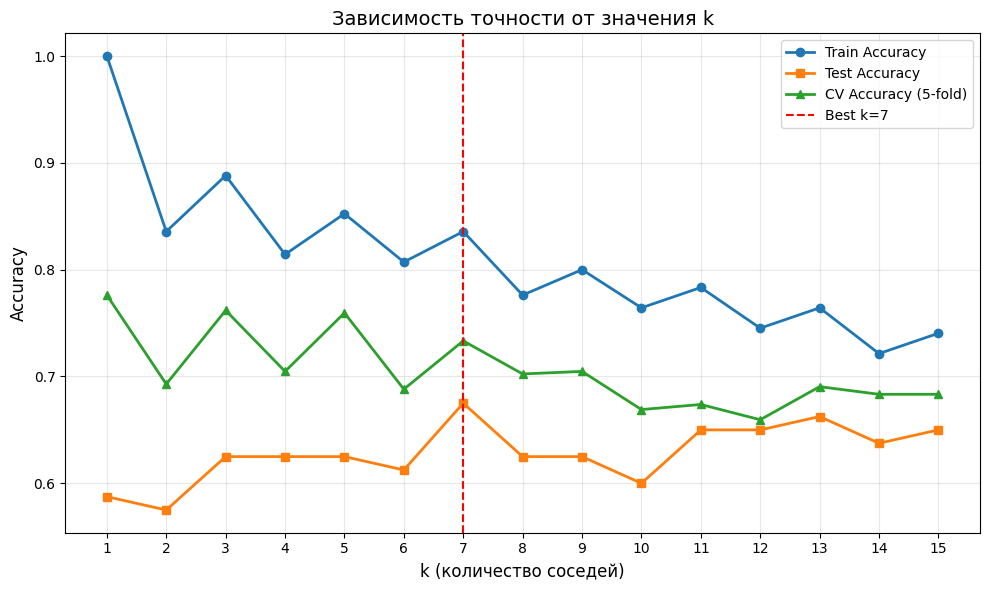

In [28]:
k_range = range(1, 16)
train_scores = []
test_scores = []
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train, y_train)
    train_acc = knn.score(X_train, y_train)
    train_scores.append(train_acc)
    
    test_acc = knn.score(X_test, y_test)
    test_scores.append(test_acc)
    
    cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy').mean()
    cv_scores.append(cv_score)

plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, 'o-', label='Train Accuracy', linewidth=2)
plt.plot(k_range, test_scores, 's-', label='Test Accuracy', linewidth=2)
plt.plot(k_range, cv_scores, '^-', label='CV Accuracy (5-fold)', linewidth=2)

best_k = k_range[np.argmax(test_scores)]
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')

plt.xlabel('k (количество соседей)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Зависимость точности от значения k', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## Многоклассовая классификация

### Привести описание датасета

**Датасет Statlog (Vehicle Silhouettes)** содержит данные о силуэтах четырёх типов транспортных средств, цель (целевой признак, таргет) — классификация силуэта как одного из четырёх типов: **Opel Manta 400, Saab 9000, Chevrolet Van, Double-decker Bus**.

| Признак | Описание |
| --- | --- |
| **Class** | Тип транспортного средства: `opel`, `saab`, `bus`, `van` |
| COMPACTNESS | Компактность: (средний периметр)² / площадь |
| CIRCULARITY | Циркулярность: (средний радиус)² / площадь |
| DISTANCE_CIRCULARITY | Циркулярность по расстоянию: площадь / (среднее расстояние от границы)² |
| RADIUS_RATIO | Отношение радиусов: (макс. радиус − мин. радиус) / средний радиус |
| PR.AXIS_ASPECT_RATIO | Соотношение осей: (малая ось) / (большая ось) |
| MAX.LENGTH_ASPECT_RATIO | Соотношение по макс. длине: (длина, перпендикулярная макс. длине) / (макс. длина) |
| SCATTER_RATIO | Отношение рассеяния: (инерция относительно малой оси) / (инерция относительно большой оси) |
| ELONGATEDNESS | Вытянутость: площадь / (ширина после сжатия)² |
| PR.AXIS_RECTANGULARITY | Прямоугольность по главной оси: площадь / (длина гл. оси × ширина гл. оси) |
| MAX.LENGTH_RECTANGULARITY | Прямоугольность по макс. длине: площадь / (макс. длина × длина, перпендикулярная ей) |
| SCALED_VARIANCE_MAJOR | Масштабированная дисперсия вдоль большой оси: (момент 2-го порядка относительно малой оси) / площадь |
| SCALED_VARIANCE_MINOR | Масштабированная дисперсия вдоль малой оси: (момент 2-го порядка относительно большой оси) / площадь |
| SCALED_RADIUS_GYRATION | Масштабированный радиус инерции: (дисперсия по большой оси + дисперсия по малой оси) / площадь |
| SKEWNESS_MAJOR | Асимметрия относительно большой оси: (момент 3-го порядка относительно большой оси) / σ_min³ |
| SKEWNESS_MINOR | Асимметрия относительно малой оси: (момент 3-го порядка относительно малой оси) / σ_maj³ |
| KURTOSIS_MAJOR | Эксцесс относительно большой оси: (момент 4-го порядка относительно большой оси) / σ_min⁴ |
| KURTOSIS_MINOR | Эксцесс относительно малой оси: (момент 4-го порядка относительно малой оси) / σ_maj⁴ |
| HOLLOWS_RATIO | Отношение полостей: (площадь полостей) / (площадь описанного многоугольника), где площадь полостей = площадь описанного многоугольника − площадь объекта

In [29]:
df2.head()

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO,class
0,95.0,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91.0,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104.0,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93.0,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85.0,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


### Осуществить предобработку данных – "подчистить данные"

In [30]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   COMPACTNESS                       845 non-null    float64
 1   CIRCULARITY                       846 non-null    int64  
 2   DISTANCE CIRCULARITY              846 non-null    int64  
 3   RADIUS RATIO                      846 non-null    int64  
 4   PR.AXIS ASPECT RATIO              846 non-null    int64  
 5   MAX.LENGTH ASPECT RATIO           846 non-null    int64  
 6   SCATTER RATIO                     846 non-null    int64  
 7   ELONGATEDNESS                     846 non-null    int64  
 8   PR.AXIS RECTANGULARITY            846 non-null    int64  
 9   MAX.LENGTH RECTANGULARITY         846 non-null    int64  
 10  SCALED VARIANCE ALONG MAJOR AXIS  846 non-null    int64  
 11  SCALED VARIANCE ALONG MINOR AXIS  846 non-null    int64  
 12  SCALED RADIUS OF GY

Есть одно пропущенное значение COMPACTNESS. Просто удалим эту строку в данных.

In [31]:
df2.dropna(inplace=True)

### Закодировать категориальные признаки при необходимости

In [32]:
le = LabelEncoder()
df2['class'] = le.fit_transform(df2['class'])
le.classes_

array(['bus', 'opel', 'saab', 'van'], dtype=object)

### Разбить выборку на обучающую и тестовую.

> Разбиение использовать одно и то же для данных без фильтрации признаков и с применением фильтрации.

In [33]:
X = df2.drop(columns=["class"])
y = df2["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Нормализовать данные

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### При наличии дисбаланса классов снизить дисбаланс классов

In [35]:
df2['class'].value_counts(normalize=True)

class
2    0.256805
0    0.256805
1    0.250888
3    0.235503
Name: proportion, dtype: float64

Дисбаланс отсутствует

### Выбрать какое-нибудь значение гиперпараметра $k$ алгоритма $kNN$

In [36]:
knn = KNeighborsClassifier(n_neighbors=3)

### Осуществить многоклассовую классификацию

In [37]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`

In [38]:
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
class_report = classification_report(y_test, y_pred, target_names=['bus', 'opel', 'saab', 'van'])

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (macro):    {precision_macro:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (macro):        {recall_macro:.4f}")
print(f"Recall (weighted):    {recall_weighted:.4f}")
print(f"F1-Measure (macro):    {f1_macro:.4f}")
print(f"F1-Measure (weighted): {f1_weighted:.4f}")
print("\nCLASSIFICATION REPORT")
print(class_report)

Accuracy:  0.7041
Precision (macro):    0.6932
Precision (weighted): 0.7071
Recall (macro):        0.6966
Recall (weighted):    0.7041
F1-Measure (macro):    0.6919
F1-Measure (weighted): 0.7025

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         bus       0.88      0.94      0.91        49
        opel       0.41      0.50      0.45        34
        saab       0.61      0.48      0.53        48
         van       0.87      0.87      0.87        38

    accuracy                           0.70       169
   macro avg       0.69      0.70      0.69       169
weighted avg       0.71      0.70      0.70       169



### Построить `сorrelation heatmap` и/или воспользоваться методом `corr()`. Выбрать наиболее важные признаки эвристически или на основании каких-нибудь вычислений

#### Сorrelation heatmap

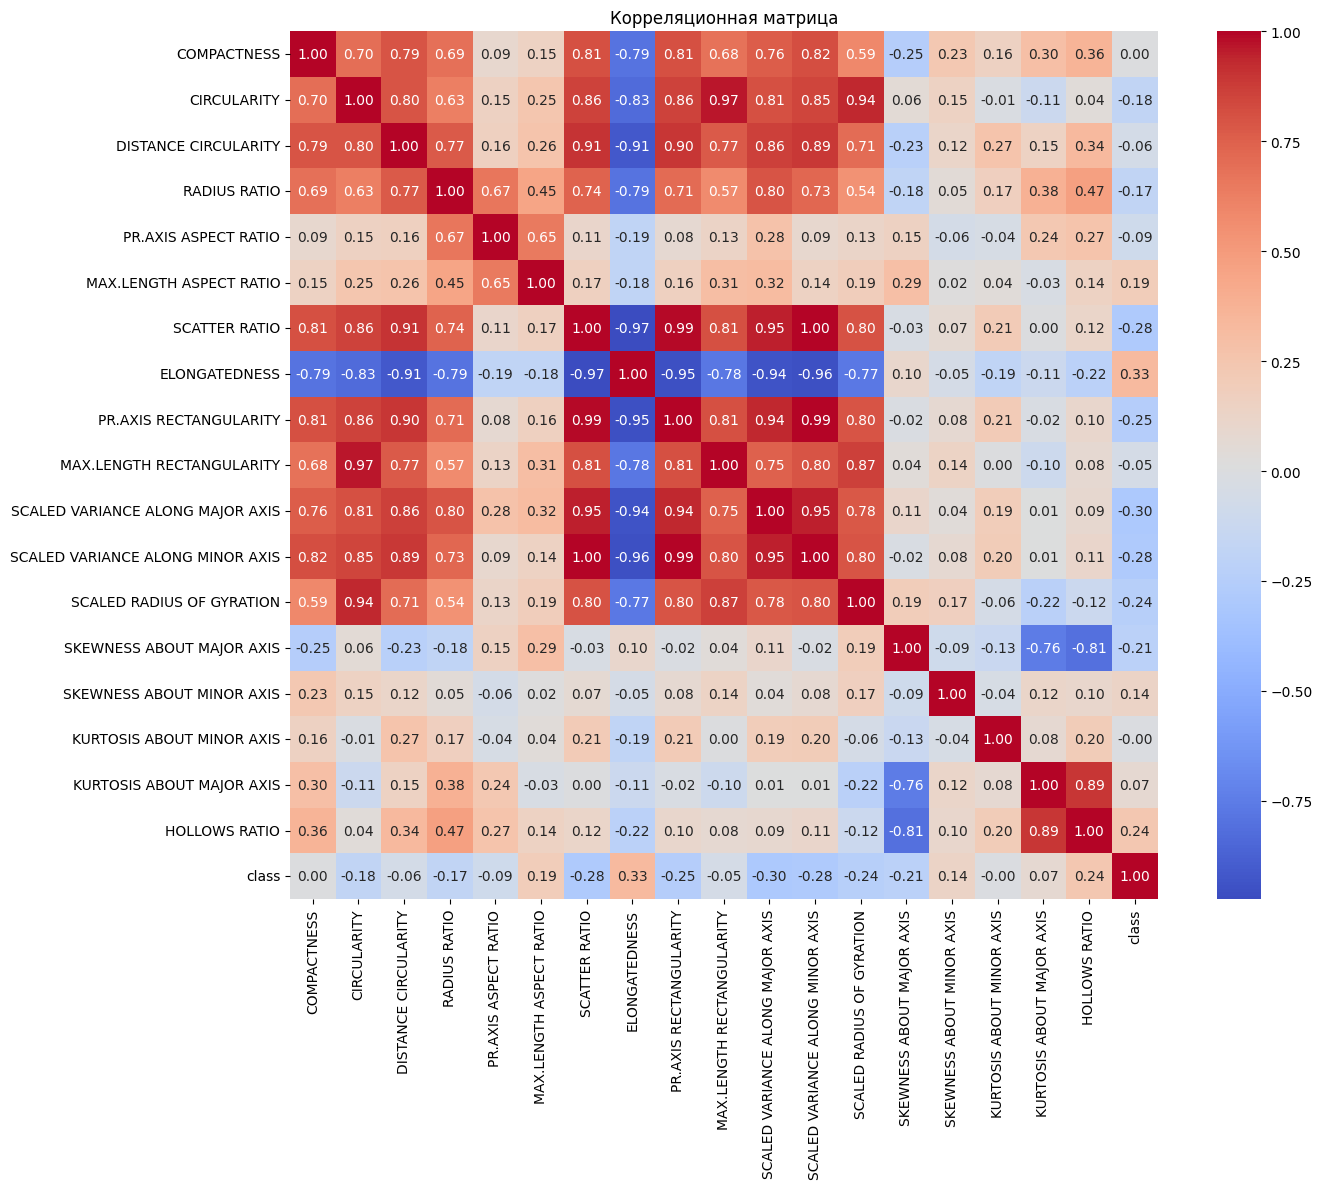

In [39]:
M_corr = df2.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(M_corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            square=True)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

#### Фильтрация признаков

In [40]:
knn_s = KNeighborsClassifier(n_neighbors=3)
sfs = SequentialFeatureSelector(knn_s, direction='forward', n_features_to_select='auto', cv=5)

sfs.fit(X_train, y_train)
X_train_filtered = sfs.transform(X_train)
X_test_filtered = sfs.transform(X_test)

print(f"Осталось признаков: {sfs.n_features_to_select_}")

Осталось признаков: 9


### Осуществить многоклассовую классификацию с отфильтрованными признаками

In [41]:
knn_f = KNeighborsClassifier(n_neighbors=3)
knn_f.fit(X_train_filtered, y_train)
y_pred_f = knn_f.predict(X_test_filtered)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`

In [42]:
accuracy_f = accuracy_score(y_test, y_pred_f)
precision_macro_f = precision_score(y_test, y_pred_f, average='macro')
precision_weighted_f = precision_score(y_test, y_pred_f, average='weighted')
recall_macro_f = recall_score(y_test, y_pred_f, average='macro')
recall_weighted_f = recall_score(y_test, y_pred_f, average='weighted')
f1_macro_f = f1_score(y_test, y_pred_f, average='macro')
f1_weighted_f = f1_score(y_test, y_pred_f, average='weighted')
class_report_f = classification_report(y_test, y_pred_f, target_names=['bus', 'opel', 'saab', 'van'])

print(f"Accuracy:  {accuracy_f:.4f}")
print(f"Precision (macro):    {precision_macro_f:.4f}")
print(f"Precision (weighted): {precision_weighted_f:.4f}")
print(f"Recall (macro):        {recall_macro_f:.4f}")
print(f"Recall (weighted):    {recall_weighted_f:.4f}")
print(f"F1-Measure (macro):    {f1_macro_f:.4f}")
print(f"F1-Measure (weighted): {f1_weighted_f:.4f}")
print("\nCLASSIFICATION REPORT")
print(class_report_f)

Accuracy:  0.7337
Precision (macro):    0.7275
Precision (weighted): 0.7363
Recall (macro):        0.7263
Recall (weighted):    0.7337
F1-Measure (macro):    0.7249
F1-Measure (weighted): 0.7329

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         bus       0.83      0.92      0.87        49
        opel       0.47      0.53      0.50        34
        saab       0.66      0.56      0.61        48
         van       0.94      0.89      0.92        38

    accuracy                           0.73       169
   macro avg       0.73      0.73      0.72       169
weighted avg       0.74      0.73      0.73       169



### Сравнить результаты "до" и "после" фильтрации, сделать выводы

In [43]:
comparison_data = {
    'Метрика': [
        'Accuracy', 
        'Precision (macro)', 
        'Precision (weighted)', 
        'Recall (macro)', 
        'Recall (weighted)', 
        'F1-Macro', 
        'F1-Weighted'
    ],
    'До': [
        accuracy, 
        precision_macro, 
        precision_weighted, 
        recall_macro, 
        recall_weighted, 
        f1_macro, 
        f1_weighted
    ],
    'После': [
        accuracy_f, 
        precision_macro_f,
        precision_weighted_f, 
        recall_macro_f, 
        recall_weighted_f,
        f1_macro_f, 
        f1_weighted_f
    ],
    'Разница': [
        accuracy_f - accuracy, 
        precision_macro_f - precision_macro, 
        precision_weighted_f - precision_weighted, 
        recall_macro_f - recall_macro, 
        recall_weighted_f - recall_weighted, 
        f1_macro_f - f1_macro, 
        f1_weighted_f - f1_weighted
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Метрика,До,После,Разница
0,Accuracy,0.704142,0.733728,0.029586
1,Precision (macro),0.693233,0.727500,0.034266
2,Precision (weighted),0.707079,0.736315,0.029236
3,Recall (macro),0.696591,0.726254,0.029663
4,Recall (weighted),0.704142,0.733728,0.029586
5,F1-Macro,0.691882,0.724862,0.032979
6,F1-Weighted,0.702494,0.732888,0.030394


Фильтрация признаков обеспечила стабильный прирост качества модели KNN: все метрики улучшились примерно на 3 п.п. (Accuracy +0,03, F1-macro +0,033, F1-weighted +0,03), причём рост зафиксирован как для macro-, так и для weighted-усреднения, что говорит об улучшении предсказаний по всем классам. Это подтверждает, что удаление шумовых и малоинформативных признаков позволило алгоритму, опирающемуся на метрики расстояния, более точно определять ближайших соседей, снизив влияние нерелевантных переменных и повысив общую обобщающую способность модели без перекоса в сторону отдельных классов.

### Перебрать значения гиперпараметра $k$ в каком-нибудь диапазоне с использованием кросс-валидации на данных
> данных &ndash; исходных данных до разбиения с применением нормализации с отфильтрованными признаками. Построить график *train/test accuracy* в зависимости от значения $k$.

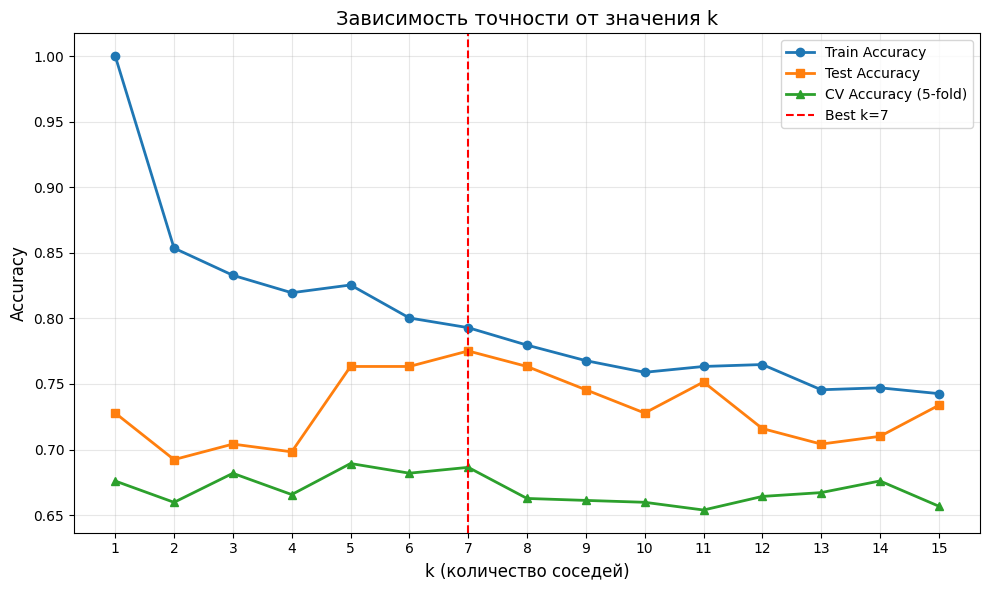

In [44]:
k_range = range(1, 16)
train_scores = []
test_scores = []
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train, y_train)
    train_acc = knn.score(X_train, y_train)
    train_scores.append(train_acc)
    
    test_acc = knn.score(X_test, y_test)
    test_scores.append(test_acc)
    
    cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy').mean()
    cv_scores.append(cv_score)

plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, 'o-', label='Train Accuracy', linewidth=2)
plt.plot(k_range, test_scores, 's-', label='Test Accuracy', linewidth=2)
plt.plot(k_range, cv_scores, '^-', label='CV Accuracy (5-fold)', linewidth=2)

best_k = k_range[np.argmax(test_scores)]
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')

plt.xlabel('k (количество соседей)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Зависимость точности от значения k', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()